In [1]:
from optimizer import Optimizer
from chromosome import Chromosome
from character import Character
from utils import get_item_set, elements
import os
from data import items, item_sets
import json
from datetime import datetime

In [2]:
config = {
            "optimizer" : {
                "path" : f"outputs/ocra-omni-crit-weapon/{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}",
                "language": "es",
                "population_size": 300,
                "num_parents_mating": 100, # Number of parents to mate, usually 1/3 of population size
                "num_generations": 400,
                "mutation_rate": 0.05,
                "crossover_rate": 0.8,
                "parent_selection_type": "tournament",  # Tournament Selection
                "tournament_size": 3,
                "exclusions": {
                    "items": [6894,
                              6895,
                              3080,
                              9031,
                              8575,
                              6980, # Vulbis
                              13344, # Dolmanax
                              ]  # Excluded items
                },
                "inclusions": {
                    "items": [
                        # 15190, # Brazalete melenutrof exo PM
                        # 17579, # Casco de miauvizor exo PA
                        7754, # Dofus ocre
                    ]
                },
                "preferences": {
                    "lower": {
                        12: {
                            "target": 12,  # AP
                            "strength": 0.9,  # Penalty for not meeting the target
                        },
                        8: {
                            "target": 6,  # MP
                            "strength": 0.9,  # Penalty for not meeting the target
                        },
                        29: {
                            "target": 85,  # Crit
                            "strength": 0.75,  # Penalty for not meeting the target
                        },
                        9: {
                            "target": 3500,  # Vit
                            "strength": 0.5,  # Penalty for not meeting the target
                        },
                        34 : {
                            "target": 15, # %res neutral
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        37 : {
                            "target": 15, # %res fire
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        16 : {
                            "target": 15, # %res air
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        17 : {
                            "target": 15, # %res water
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        63 : {
                            "target": 15, # %res range
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        31 : {
                            "target": 6, # range
                            "strength": 0.75,  # Penalty for not meeting the target
                        }
                    },
                    "upper": {}
                },
                "level_offset": 10,  # Level offset for items
                "objective": "weapon",  # Objective to optimize, can be "weapon" or "elements"
                # "normalize_by_apcost" : False # If False, only care about absolute damage regardless of AP cost
            },
            "character": {
                "level": 200,
                "scrolled": True,
                "exo": {
                    12:1, # Exo AP
                    8:1,  # Exo MP
                    31:1, # Exo Range
                    },
                "distributed_points": {
                    # 9: 995,  # Vitality
                },
                "elements" : [
                    36, # Agility,
                    22, # Chance
                    13, # Intelligence
                    45  # Strength
                ],
                "melee" : False,
                "ranged" : 7
            },
        }

if not os.path.exists(config["optimizer"]["path"]):
    os.makedirs(config["optimizer"]["path"], exist_ok=True)

with open(config["optimizer"]["path"] + '/config.json', 'w') as file:
    json.dump(config, file, indent=4)

In [3]:
import pandas as pd
dct = {}
for k,v in items.items():
    item_set = get_item_set(v,item_sets)
    dct[k] = {
        "name" : v["name"][config["optimizer"]["language"]],
        "set" : item_set["name"][config["optimizer"]["language"]] if item_set else None,
        "level" : v["level"]
    }
Items = pd.DataFrame.from_dict(dct, orient='index')
# Exclude items from the Gargandias set
config["optimizer"]["exclusions"]["items"] += Items[Items["set"].str.contains("Set de Gargandias",na=False,case=False)].index.tolist()

In [4]:
char = Character(**config["character"])
opt = Optimizer(char,
                 items,
                   item_sets,
                     **config["optimizer"])

Total items: 11256
Total item sets: 565
Total pools:
   16 with sizes [72, 15, 82, 82, 65, 83, 45, 93, 72, 9780, 1, 293, 293, 293, 293, 293]
Total combinations: 10^32.40


In [5]:
solutions = opt.optimize(islands = 10, max_workers = 4)

/Users/jdtibochab/other/dofus-set-optimizer/.venv/lib/python3.12/site-packages/pygad/utils/validation.py:1914: UserWarning: Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.
  warnings.warn("Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.")
/Users/jdtibochab/other/dofus-set-optimizer/.venv/lib/python3.12/site-packages/pygad/utils/validation.py:1914: UserWarning: Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.
  warnings.warn("Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.")
/Users/jdtibochab/other/dofus-set-optimizer/.venv/lib/python3.12/site-packages/pygad/utils/validation.py:1

## Analysis

In [6]:
from analysis import Analyzer
analyzer = Analyzer(opt, solutions)
analyzer.run_analysis()

Number of candidate solutions: 8


In [7]:
analyzer.report_extended_results()

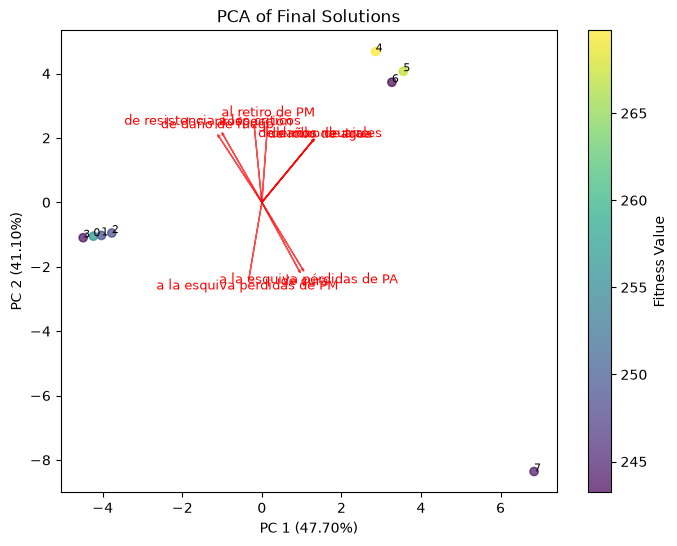

In [8]:
analyzer.plot_pca()

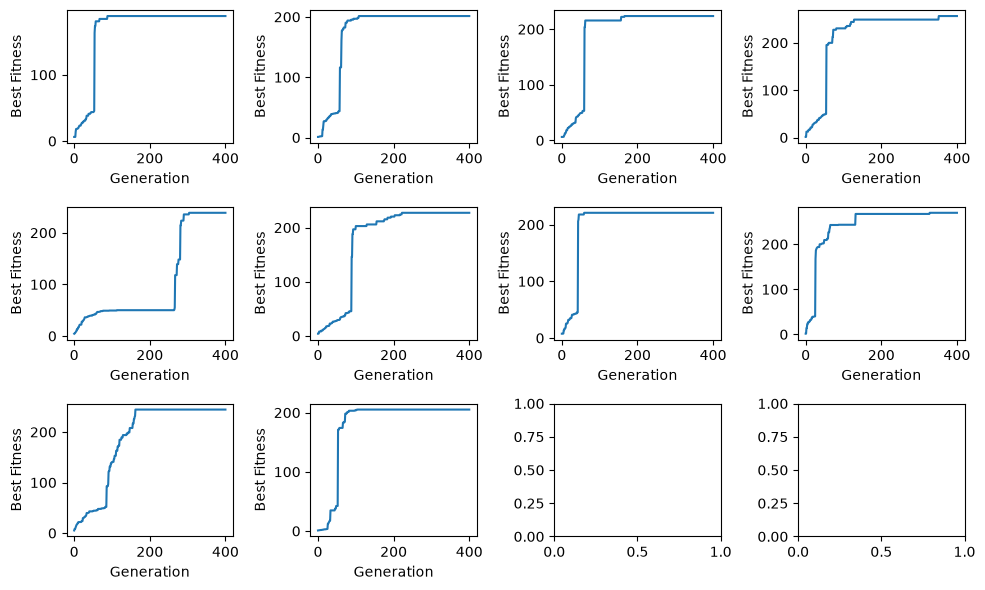

In [9]:
analyzer.report_generations()

In [10]:
assert False

AssertionError: 

In [ ]:
# Current
chr = Chromosome([
			19984, # Collar vuelo
			15190, # Brazalete de melenutrof
			19985, # Anillo de vuelo
			19986, # Arco de vueloceronte
			17578, # Botas de Miauvizor
			17580, # Capa de Miauvizor
			19983, # Cinto vuelo
			694, # Dofus Púrpura
			739, # Dofus Turquesa
			7043, # Dofus de los hielos
			7754, # Dofus Ocre
			18700, # Cuadrifolio
			13673, # Lokulto
			17579, # Casco de Miauvizor
			13825, # Potente mayor
			7754, # Espabilador
			],
                 opt)
chr.fitness, chr.get_final_damage("weapon")

(7.169496776470587, 1504.7091999999998)

In [ ]:
from analysis import Analyzer
analyzer = Analyzer(opt, [chr])
analyzer.report_results([chr],)

In [ ]:
Items[Items["set"].str.contains("miauvi",case=False,na=False)]  # Items from the Vueloceronte set

,name,set,level


In [ ]:
Items[Items["set"].str.contains("vuelo",case=False,na=False)]  # Items from the Vueloceronte set

In [ ]:
Items[Items["name"].str.contains("Dofus",case=False,na=False)]  # Items from the Vueloceronte set

,name,set,level
20833,Dofus cacao,NaN,50
29136,Dofus silvestre,NaN,180
18796,Copa DOFUS,NaN,1
20987,Dofus cacao,NaN,50
20130,Réplica del dofus Púrpura,NaN,1
19398,Dofus forjalava,NaN,180
26066,Dofus de pesadilla,NaN,180
23240,Dofus de tinta translúcido,NaN,1
7114,Dofus Ébano,NaN,180
6962,Regalo dofusiano,NaN,1


In [ ]:
# Project
chr = Chromosome(
                 [
                    8993, # Espada
                    13641, 13642, # Noai
                    14161, 14162, 14169, # Charlatan
                    14092, 14093, 18718, # Kuko
                    13673, # Lokulto
                    739, 694, 7754, 737, 7043, 17078 # Dofus
                 ],
                 opt)
chr.fitness

In [ ]:
chr.set_summary()

In [ ]:
chr.set_summary()["set"].value_counts()

In [ ]:
chr.totals_summary(effect_descriptions)

In [ ]:
Items[Items["name"].str.contains("Chani")]

In [ ]:
item = items[21392]
# item = items[6981]

In [ ]:
chr.are_item_conditions_met(item)

In [ ]:
item

In [ ]:
Items

In [ ]:
lst

In [ ]:
lst[0][2]

In [ ]:
chr.are_item_conditions_met(items[11738])

In [ ]:
items[11738]["conditions"]

In [ ]:
chr.totals[8]

In [ ]:
lst = []
for i in items.values():
    if i["type"]["superTypeId"] not in [i[0] for i in opt.pool_types]:
        continue
    if i["conditions"]:
        print(opt.solution.are_item_conditions_met(i))
        lst.append((i,opt.solution.are_item_conditions_met(i)))

In [ ]:
lst[1]

In [ ]:
lst.count(True), lst.count(False)